Martín Torres

Architectural Engineering PhD Candidate, University of Colorado Boulder

Dr. Wil Srubar's Living Materials Laboratory

mtorres2941@gmail.com

# Import packages

In [1]:
from itertools import product
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

dpi=600

# Import data

In [2]:
filename = 'data/raw/SurveyStudyAnalysis.xlsx'

df_se2050 = pd.read_excel(filename, sheet_name='SE2050')
df_aia2030 = pd.read_excel(filename, sheet_name='A2030')
df_demog = pd.read_excel(filename, sheet_name='SurveyResults')
df_tags = pd.read_excel(filename, sheet_name='Tagging')

# replace nan with None in sustainability certifications
cat = 'Sustainability Certifications'
df_demog[cat] = df_demog[cat].replace({np.nan: 'None'})

# get rid of nans in tags
col = 'TAG2'
df_tags = df_tags.loc[df_tags[col] != 'N/A:']

# get rid of repeat tags for each interview
comments = []
rows2del = []
for row in df_tags.index:
    comment = df_tags.loc[row, 'ID'] + df_tags.loc[row, 'TAG2']
    if comment in comments:
        rows2del.append(row)
    else:
        comments.append(comment)
df_tags = df_tags.loc[~df_tags.index.isin(rows2del)]

# Realign CATEGORY with TAG2.
#
# TAG1 is the original coding pass; TAG2 is the retagged (final) pass, and every
# TAG2 value is prefixed with its own category. The CATEGORY column was written
# against TAG1 and is stale, so CATEGORY-based groupings disagree with
# TAG2-based ones. Two symptoms:
#   - CATEGORY 'RESOURCES' has no TAG2 counterpart at all; retagging folded it
#     into 'LEARNING:'.
#   - Individual tags are split across categories, e.g. four participants'
#     'PROBLEM: It is difficult to (quantify materials)' rows sit under
#     CATEGORY 'TIME', undercounting that tag as 14 participants instead of 18.
#
# Derive CATEGORY from the TAG2 prefix and keep the original for reference.
df_tags['CATEGORY_TAG1'] = df_tags['CATEGORY']
df_tags['CATEGORY'] = df_tags[col].str.split(':').str[0].str.strip()

n_realigned = (df_tags['CATEGORY'] != df_tags['CATEGORY_TAG1']).sum()
print(f'{n_realigned} of {len(df_tags)} tag rows realigned to their TAG2 prefix')
print('categories dropped from CATEGORY:',
      sorted(set(df_tags['CATEGORY_TAG1'].dropna()) - set(df_tags['CATEGORY'])))

212 of 2742 tag rows realigned to their TAG2 prefix
categories dropped from CATEGORY: ['RESOURCES']


# Exploratory Data Analysis

## demographic info

In [3]:
dct_education = {
    'AA General Studies': 'AA/AS',
    'AAS Natural Resources': 'AA/AS',
    'AS Architectural Technology': 'AA/AS',
    'BA Art': 'BA/BS Other',
    'BA Liberal Studies': 'BA/BS Other',
    'BA Physics': 'BA/BS Other',
    'BA Unspecified': 'BA/BS Other',
    'BArch': 'BA/BS/BArch',
    'BFA Architectural Design': 'BA/BS/BArch',
    'BS Architectural Engineering': 'BS Civil Engineering',
    'BS Architectural Studies': 'BA/BS/BArch',
    'BS Architecture': 'BA/BS/BArch',
    'BS Civil Engineering': 'BS Civil Engineering',
    'BS Environmental Design': 'BA/BS Sustainability',
    'BS Environmental Studies': 'BA/BS Sustainability',
    'BS Interior Architecture': 'BA/BS/BArch',
    'BS Mechanical Engineering': 'BA/BS Other',
    'BS Structural Engineering': 'BS Civil Engineering',
    'MA Ecological Design': 'MA/MS Sustainability',
    'MA Landscape Architecture': 'MA/MS/MArch',
    'MA Organization Development': 'MA/MS Other',
    'MArch': 'MA/MS/MArch',
    'MArch I': 'MA/MS/MArch',
    'MS Architectural Engineering': 'MS Civil Engineering',
    'MS BIM': 'MA/MS Other',
    'MS Civil Engineering': 'MS Civil Engineering',
    'MS Construction Engineering': 'MS Civil Engineering',
    'MS Energy Efficient & Environmental Building Design': 'MA/MS Sustainability',
    'MS High Performance Buildings': 'MA/MS Sustainability',
    'MS Structural Engineering': 'MS Civil Engineering',
    'MS Sustainable Design': 'MA/MS Sustainability',
    'MS Transportation Engineering': 'MA/MS Other',
}

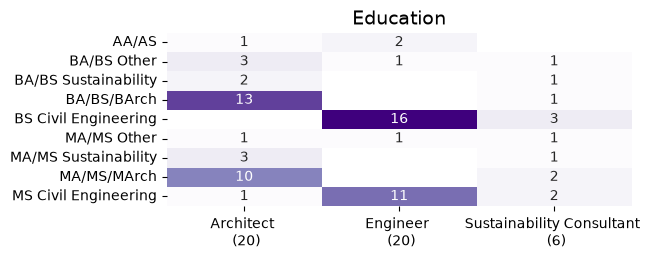

In [4]:
# education
col = 'Education'

# initialize dataframe
degrees = list(set(dct_education.values()))
degrees.sort()
dft = pd.DataFrame(data=0, index=degrees, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].values:
        for deg in degs.split(', '):
            deg = dct_education[deg]
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_Education.png', bbox_inches='tight', dpi=dpi)

In [5]:
# sustainability certification
cat = 'Sustainability Certifications'
sust_certs = []
for val in df_demog[cat].values:
    sust_certs += val.split(', ')
sust_certs = list(set(sust_certs))
sust_certs.sort()
sust_certs

['ASHRAE BEMP',
 'ActiveScore AP',
 'CPHC',
 'CPHD',
 'Construction Life-Cycle Assessment Specialist',
 'ENV SP',
 'EcoDistricts AP',
 'Fitwel Ambassador',
 'LEED AP',
 'LEED AP BD+C',
 'LEED AP ID+C',
 'LEED Fellow',
 'LEED GA',
 'LFA',
 'NFRC Certified Simulator',
 'None',
 'SITES AP',
 'WELL AP']

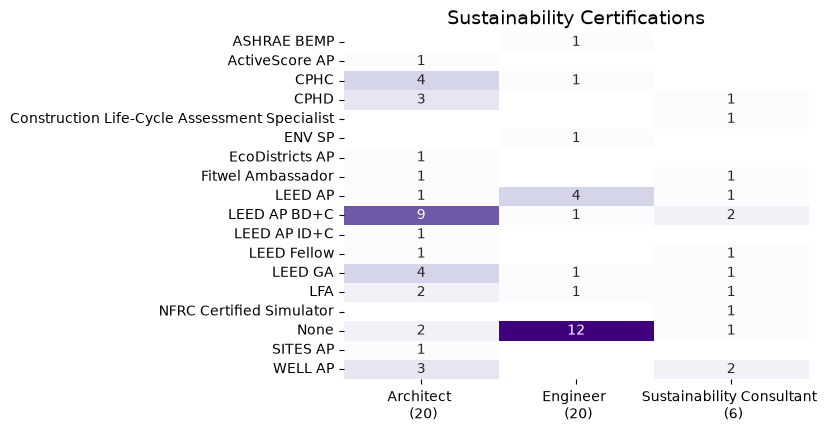

In [6]:
# education
col = 'Sustainability Certifications'

# initialize dataframe
dft = pd.DataFrame(data=0, index=sust_certs, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].values:
        for deg in degs.split(', '):
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_SustCerts.png', bbox_inches='tight', dpi=dpi)


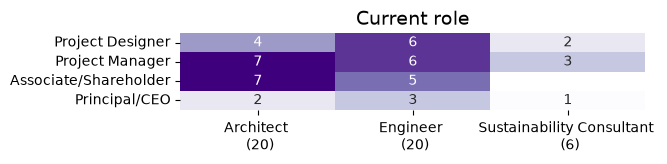

In [7]:
# current role
col = 'Current role'

# initialize dataframe
roles = [
    'Project Designer',
    'Project Manager',
    'Associate/Shareholder',
    'Principal/CEO',
]
dft = pd.DataFrame(data=0, index=roles, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].values:
        for deg in degs.split(', '):
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_CurrentRole.png', bbox_inches='tight', dpi=dpi)


In [8]:
# sustainability certification
cat = 'Licensure'
licenses = []
for val in df_demog[cat].dropna().values:
    licenses += val.split(', ')
licenses = list(set(licenses))
licenses.sort()
licenses

['AIA', 'Assoc. AIA', 'NCARB', 'PE', 'RA', 'SE']

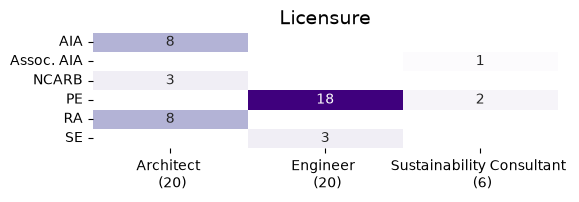

In [9]:
# Licensure

# education
col = 'Licensure'

# initialize dataframe
dft = pd.DataFrame(data=0, index=licenses, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].dropna().values:
        for deg in degs.split(', '):
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_Licensure.png', bbox_inches='tight', dpi=dpi)


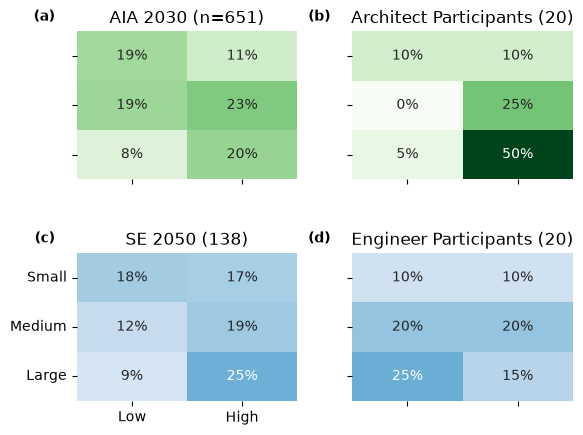

In [10]:
# firm size and involvement relative to SE 2050 and AIA 2030
col1 = 'Firm Size'
col2 = 'Involvement'
cmap = 'Blues'

fig, axes = plt.subplots(2,2, gridspec_kw=dict(hspace=0.5, wspace=0.25))



# architecture, population
ax = axes[0,0]
archeng = 'Architect'
dft_popu = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_aia2030['Group'].str.split('/'):
    size, inv = item
    dft_popu.loc[size, inv] += 1
dft_popu = dft_popu/dft_popu.sum().sum()
sns.heatmap(dft_popu, cmap='Greens', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"AIA 2030 (n={len(df_aia2030)})")
ax.text(-0.1,1.05,'(a)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# architecture, sample
ax = axes[0,1]
dft_samp = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_demog.loc[df_demog['Arch/Eng'] == archeng]['Group'].str.split('/'):
    size, inv = item
    dft_samp.loc[size, inv] += 1
dft_samp = dft_samp/dft_samp.sum().sum()
sns.heatmap(dft_samp, cmap='Greens', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"{archeng} Participants ({df_demog['Arch/Eng'].value_counts()['Architect']})")
ax.text(-0.1,1.05,'(b)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# engineer, population
ax = axes[1,0]
archeng = 'Engineer'
dft_popu = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_se2050['Group'].str.split('/'):
    size, inv = item
    dft_popu.loc[size, inv] += 1
dft_popu = dft_popu/dft_popu.sum().sum()
sns.heatmap(dft_popu, cmap='Blues', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"SE 2050 ({len(df_se2050)})")
ax.text(-0.1,1.05,'(c)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# engineer, sample
ax = axes[1,1]
dft_samp = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_demog.loc[df_demog['Arch/Eng'] == archeng]['Group'].str.split('/'):
    size, inv = item
    dft_samp.loc[size, inv] += 1
dft_samp = dft_samp/dft_samp.sum().sum()
sns.heatmap(dft_samp, cmap='Blues', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"{archeng} Participants ({df_demog['Arch/Eng'].value_counts()['Engineer']})")
ax.text(-0.1,1.05,'(d)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# format
for row, col in product(range(2), range(2)):
    ax = axes[row, col]
    if (row, col) == (1,0):
        ax.tick_params('y', rotation=0)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    
plt.savefig('outputs/figures/Participants_vs_CommitmentPrograms.png', bbox_inches='tight', dpi=dpi)

## tags

In [11]:
# most common tags
#
# value_counts() does not define an order among tags with equal counts, and the
# tie order differs between pandas versions. Sort the index first, then sort by
# count with a stable sort, so the exported table is reproducible: descending by
# count, then alphabetical within each tie.
col = 'TAG2'

srs = df_tags[col].value_counts()
srs = srs.sort_index(kind='stable').sort_values(ascending=False, kind='stable')
pd.Series(srs.index.values, index=srs).to_excel('outputs/tables/tagcounts.xlsx')

In [12]:
# identify each question with multiple answers
col = 'TAG2'

df_tags['(_lim'] = df_tags[col].str.find('(')

for row in df_tags.index:
    tag2 = df_tags.loc[row][col]
    lim = df_tags.loc[row]['(_lim']
    if lim != -1:
        df_tags.loc[row, f'{col}_cat'] = tag2[:lim-1]
    else:
        df_tags.loc[row, f'{col}_cat'] = np.nan

srs = df_tags['TAG2_cat'].value_counts()


In [13]:
col = 'TAG2_cat'
cats = list(df_tags[col].value_counts().index)
cats.sort()
cats

['ADVANCED LCA: A barrier to adopting advanced LCA methods may be',
 'ADVANCED LCA: Advanced LCA is better because it',
 'ADVANCED LCA: For widespread use, advanced LCA methods must',
 'ADVANCED LCA: Whether I use advanced LCA methods depends on',
 "APPLICATION: Our firm's LCA practice is",
 'APPLICATION: Reduction strategies include',
 'APPLICATION: The LCA workload is shared with other firms',
 'APPLICATION: We aspire to',
 'APPLICATION: We follow external guidelines',
 'APPLICATION: We have worked with a sustainability consultant on the LCA',
 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I',
 'BIOGENIC CARBON: How I deal with biogenic carbon depends on',
 'DATA: For embodied carbon data, we use',
 'DATA: Material quantity takeoffs come from',
 'DATA: We request EPDs on our projects',
 'DLCA: A barrier to adopting DLCA may be',
 'DLCA: Compared to traditional LCA, DLCA is better',
 'DLCA: For widespread use, DLCA must',
 'DLCA: Whether I use DLCA depends on',
 'LEARNING: A resou

In [14]:
col = 'TAG2_cat'
cat = 'DATA: For embodied carbon data, we use'
df_tags.loc[df_tags[col] == cat]['TAG2'].value_counts()

TAG2
DATA: For embodied carbon data, we use (EPDs)                                                16
DATA: For embodied carbon data, we use (EPDs from EC3)                                       14
DATA: For embodied carbon data, we use (average EPDs)                                         8
DATA: For embodied carbon data, we use (EPDs from material suppliers)                         4
DATA: For embodied carbon data, we use (LCA tool)                                             3
DATA: For embodied carbon data, we use (EPDs), NOT                                            2
DATA: For embodied carbon data, we use (EPDs from NRMCA)                                      1
DATA: For embodied carbon data, we use (EPDs from Sustainable Minds Transparency Catalog)     1
DATA: For embodied carbon data, we use (primary data)                                         1
Name: count, dtype: int64

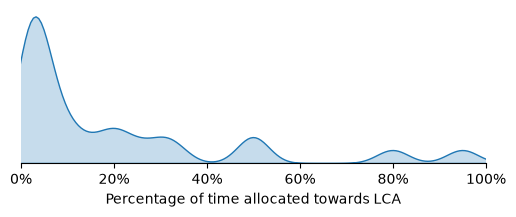

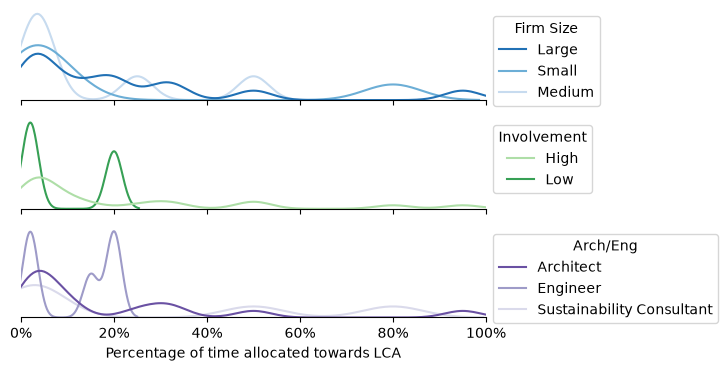

In [15]:
# TIME: The time I allocate towards LCA work is (25%)

col = 'TAG2'
cat = 'TIME: The time I allocate towards LCA work is'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
# dft[col].str[len(cat):]
srs = dft[col].str.find('%')
dft = dft.loc[srs.loc[srs>0].index]

label = 'Percentage of time allocated towards LCA'
dft[label] = dft[col].str[len(cat)+2:-2].astype(float)/100

fig, ax = plt.subplots(figsize=(6,2))
# sns.stripplot(dft[label], ax=ax, orient='h')
ax.set_xlim(0,1)
sns.kdeplot(dft[label], ax=ax, fill=True, bw_adjust=0.25)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/TimeTowardsLCA.png', bbox_inches='tight', dpi=dpi)

# add other features
fig, axes = plt.subplots(3,1, figsize=(6,4), sharex=True)

for i, (y, palette) in enumerate(zip(['Firm Size', 'Involvement', 'Arch/Eng'], ['Blues_r', 'Greens', 'Purples_r'])):
    ax = axes[i]
    dct = dict(df_demog.set_index('ID')[y])
    dft[y] = dft['ID'].map(dct)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        # sns.stripplot(data=dft, x=label, y=y, orient='h', ax=ax)
        sns.kdeplot(data=dft, x=label, hue=y, ax=ax, bw_adjust=0.25, legend=True, palette=palette, common_norm=False)
        ax.set_xlim(0,1)
        sns.move_legend(ax, bbox_to_anchor=(1,1), loc='upper left')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/TimeTowardsLCA_split.png', bbox_inches='tight', dpi=dpi)


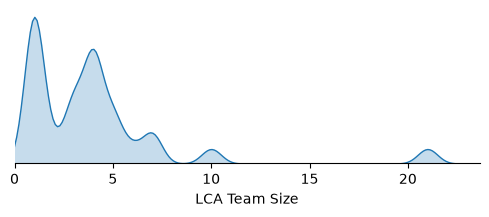

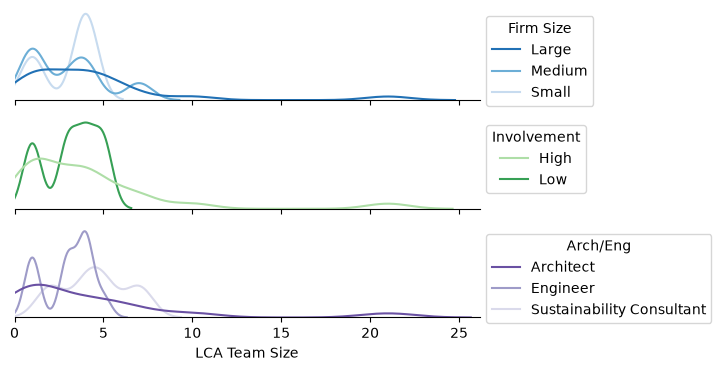

In [16]:
# TEAM: The LCA team is comprised of (1 person)
col = 'TAG2'
cat = 'TEAM: The LCA team is comprised of'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
srs = dft[col].str[len(cat)+2:]
terms = []
ind2keep = []
for ind, term, loc in zip(srs.index, srs.values, srs.str.find(' ')):
    try:
        terms.append(int(term[:loc]))
        ind2keep.append(ind)
    except:
        pass

dft = dft.loc[ind2keep]
label = 'LCA Team Size'
dft[label] = terms

fig, ax = plt.subplots(figsize=(6,2))
# sns.stripplot(dft[label], ax=ax, orient='h')
sns.kdeplot(dft[label], ax=ax, fill=True, bw_adjust=0.25)
ax.set_xlim(0,)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.savefig('outputs/figures/LCATeamSize.png', bbox_inches='tight', dpi=dpi)


# add other features
fig, axes = plt.subplots(3,1, figsize=(6,4), sharex=True)

for i, (y, palette) in enumerate(zip(['Firm Size', 'Involvement', 'Arch/Eng'], ['Blues_r', 'Greens', 'Purples_r'])):
    ax = axes[i]
    dct = dict(df_demog.set_index('ID')[y])
    dft[y] = dft['ID'].map(dct)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        # sns.stripplot(data=dft, x=label, y=y, orient='h', ax=ax)
        sns.kdeplot(data=dft, x=label, hue=y, ax=ax, bw_adjust=0.5, legend=True, palette=palette, common_norm=False)
        ax.set_xlim(0,)
        sns.move_legend(ax, bbox_to_anchor=(1,1), loc='upper left')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.savefig('outputs/figures/LCATeamSize_split.png', bbox_inches='tight', dpi=dpi)


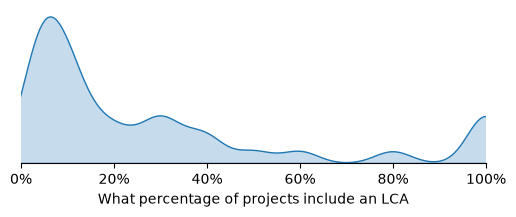

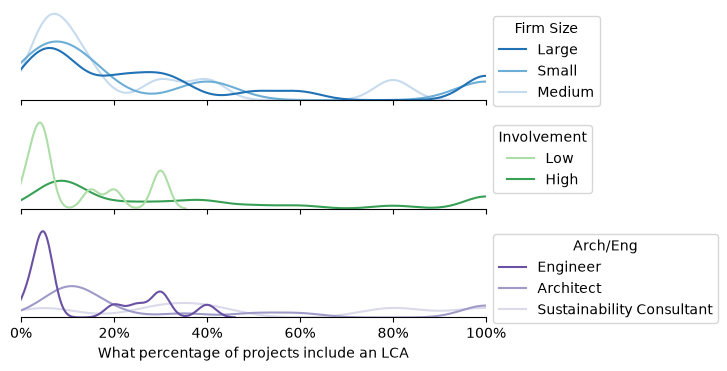

In [17]:
# PROJECTS: Our firm performs LCAs on (10% of projects)

col = 'TAG2'
cat = 'PROJECTS: Our firm performs LCAs on'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
srs = dft[col].str[len(cat):]
srs = srs.str.find('%')
dft = dft.loc[srs.loc[srs>0].index]
terms = []
for string in dft[col]:
    if string.find('-') > -1:
        string = string[string.find('-'):]
    term = ''.join(c for c in string if c.isdigit())
    terms.append(float(term)/100)

label = 'What percentage of projects include an LCA'
dft[label] = terms

fig, ax = plt.subplots(figsize=(6,2))
# sns.stripplot(dft[label], ax=ax, orient='h')
sns.kdeplot(dft[label], ax=ax, fill=True, bw_adjust=0.25)
ax.set_xlim(0,1)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/LCAProjectPercentage.png', bbox_inches='tight', dpi=dpi)


# add other features
fig, axes = plt.subplots(3,1, figsize=(6,4), sharex=True)

for i, (y, palette) in enumerate(zip(['Firm Size', 'Involvement', 'Arch/Eng'], ['Blues_r', 'Greens', 'Purples_r'])):
    ax = axes[i]
    dct = dict(df_demog.set_index('ID')[y])
    dft[y] = dft['ID'].map(dct)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        # sns.stripplot(data=dft, x=label, y=y, orient='h', ax=ax)
        sns.kdeplot(data=dft, x=label, hue=y, ax=ax, bw_adjust=0.25, legend=True, palette=palette, common_norm=False)
        ax.set_xlim(0,1)
        sns.move_legend(ax, bbox_to_anchor=(1,1), loc='upper left')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/LCAProjectPercentage_split.png', bbox_inches='tight', dpi=dpi)


/var/folders/lf/rj6_dw5n1h703r1233mlc8_rdv24s9/T/ipykernel_2735/200570655.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(yticklabels)


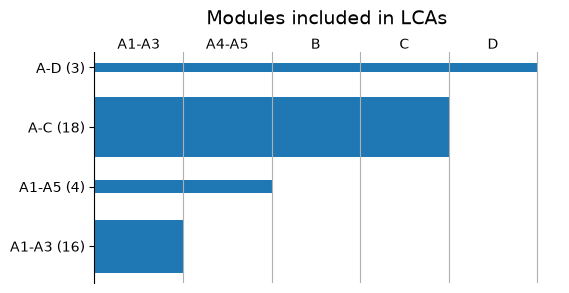

In [18]:
#SCOPE: Our LCAs include modules (A1-A3)
col = 'TAG2'
cat = 'SCOPE: Our LCAs include modules'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
dft = dft[col].str[len(cat)+2:-1].value_counts()

dict_length = {
    'A1-A3': 1,
    'A1-A5': 2,
    'A-C': 4,
    'A-D': 5,
}

dft = dft.loc[dict_length.keys()]

#data
x = dft.index
h = [dict_length[ele] for ele in dft.index]
w = dft.values/np.max(dft.values)

#bar plot
fig, ax = plt.subplots(figsize=(6,3))
ax.barh(x, height = w, width = h)
ax.grid(which='major', axis='x')

ymin, ymax = ax.get_ylim()
for x, module in enumerate(['A1-A3', 'A4-A5', 'B', 'C', 'D']):
    ax.text(x+0.5, ymax, module, ha='center', va='bottom')

ax.set_xticklabels([])
ax.tick_params(colors='white', which='major', axis='x')
yticklabels = []
for y in ax.get_yticklabels():
    yticklabels.append(f'{y.get_text()} ({dft[y.get_text()]})')
ax.set_yticklabels(yticklabels)
ax.text(x=0.5, y=1.1, s='Modules included in LCAs', ha='center', va='bottom', transform=ax.transAxes, fontsize=14)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

plt.savefig('outputs/figures/LCAModules.png', bbox_inches='tight', dpi=dpi)


In [19]:
# Motivation rollups: how many participants cite each kind of institution?
#
# Tags carry an explicit negation suffix (', NO' / ', NOT') for participants who
# said an institution is NOT a motivator. Matching on the prefix alone counts
# those as positives, so exclude them.
col = 'TAG2'
MOTIV = "MOTIVATION: Our firm's motivation for LCA is ("
is_neg = df_tags[col].str.contains(', NO', na=False)
n_total = len(df_demog)

rollups = {
    'green building certifications': 'GBC',
    'policy':                        'Policy',
    'commitment programs':           'CP',
}

for label, key in rollups.items():
    mask = df_tags[col].str.startswith(MOTIV + key) & ~is_neg
    n = df_tags.loc[mask, 'ID'].nunique()
    n_excluded = df_tags.loc[df_tags[col].str.startswith(MOTIV + key) & is_neg, 'ID'].nunique()
    note = f'  (excludes {n_excluded} who named it as a non-motivator)' if n_excluded else ''
    print(f'{n} of {n_total} ({n / n_total:.0%}) cite {label}{note}')

# individual programmes, for reference
print()
for key in ['CP - SE 2050', 'CP - AIA 2030', 'GBC - LEED']:
    mask = df_tags[col].str.startswith(MOTIV + key) & ~is_neg
    n = df_tags.loc[mask, 'ID'].nunique()
    print(f'  {key:<14} {n} of {n_total} ({n / n_total:.0%})')


32 of 46 (70%) cite green building certifications  (excludes 3 who named it as a non-motivator)
23 of 46 (50%) cite policy  (excludes 3 who named it as a non-motivator)
31 of 46 (67%) cite commitment programs  (excludes 1 who named it as a non-motivator)

  CP - SE 2050   22 of 46 (48%)
  CP - AIA 2030  14 of 46 (30%)
  GBC - LEED     26 of 46 (57%)


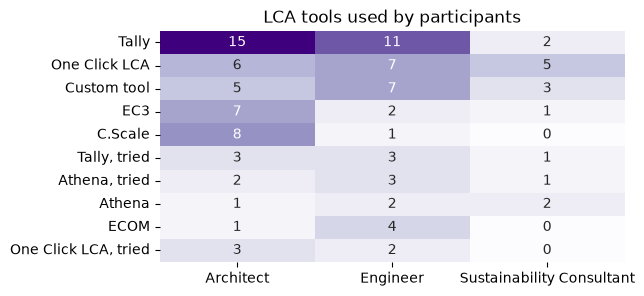

In [20]:
# architects vs engineers LCA tools used
col = 'TAG2'
cat = 'TOOL: To perform LCA, our firm uses'

# prepare dataframe
dft = df_tags.loc[df_tags[col].str.startswith(cat)]

# add in arch/eng split
split = 'Arch/Eng'
dct = dict(df_demog.set_index('ID')[split])
dft[split] = dft['ID'].map(dct)
srs = dft[col].str[len(cat):]

# get a list of all tools
tools = list(dft[col].str[len(cat)+2:-1].unique())
tools.sort()

# add value counts ot plot
dft_plot = pd.DataFrame(index=tools, columns=['Architect', 'Engineer', 'Sustainability Consultant'])
for archeng in dft[split].unique():
    srs = dft.loc[dft[split] == archeng][col].str[len(cat)+2:-1]
    dft_plot[archeng] = srs.value_counts()

dft_plot = dft_plot.fillna(0.)
dft_plot['Total'] = dft_plot.sum(axis=1)
dft_plot = dft_plot.sort_values('Total', ascending=False)
# plot
fig, ax = plt.subplots(figsize=(6,3))
sns.heatmap(dft_plot.iloc[:10,:-1], cmap='Purples', annot=True, cbar=False, ax=ax)
ax.set_title('LCA tools used by participants')

plt.savefig('outputs/figures/Demographics_LCATool.png', bbox_inches='tight', dpi=dpi)


# High level takeaways

## institutional support is critical

In [21]:
# institutional support is critical
col = 'TAG2_cat'
tag2_cat = 'LEARNING: A resource I use for learning LCA is'
df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts()

TAG2
(on the job)                                27
(CLF)                                       17
(In-House Resources)                        14
(SE 2050)                                   13
(university)                                11
(peer network)                               6
(Tally)                                      5
(online search)                              4
(One Click LCA)                              3
(SEI Prestandard)                            3
(software tutorials)                         3
(AIA)                                        2
(Athena)                                     2
(EPDs)                                       2
(IStructE)                                   2
(LCA tool customer support)                  2
(LEED)                                       2
(USGBC)                                      2
(ASCE)                                       1
(Autodesk)                                   1
(book)                                       1
(C.Scale

In [22]:
# institutional support is critical
col = 'TAG2_cat'
tag2_cat = "MOTIVATION: Our firm's motivation for LCA is"
srs = df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts()
srs.loc[srs.index.str.startswith(' (GBC')]

TAG2
(GBC - LEED)            26
(GBC)                   10
(GBC - ILFI/ZCC)         4
(GBC - WELL)             4
(GBC - ILFI/LBC)         3
(GBC, NO)                2
(GBC - Active Score)     1
(GBC - Envision)         1
(GBC - Green Globes)     1
(GBC - ILFI)             1
(GBC - LEED, NO)         1
(GBC - UN Compact)       1
Name: count, dtype: int64

In [23]:
df_tags.loc[df_tags['CATEGORY']=='PROBLEM']['TAG2'].value_counts()

TAG2
PROBLEM: A problem with LCAs is (data inaccuracy)                                                     43
PROBLEM: A problem with LCAs is (reliability of results)                                              28
PROBLEM: It is difficult to (navigate BIM)                                                            26
PROBLEM: A problem with LCAs is (lack of standardization)                                             24
PROBLEM: It is difficult to (define an EC benchmark)                                                  19
PROBLEM: It is difficult to (quantify materials)                                                      18
PROBLEM: A problem with LCAs is (LCAs are under valued)                                               16
PROBLEM: A problem with LCAs is (results are not interpretable)                                       14
PROBLEM: It is difficult to (train others to do LCA)                                                  14
PROBLEM: QUOTE                                    

In [24]:
# institutional support is critical
col = 'TAG2_cat'
tag2_cat = 'PROBLEM: It is difficult to'
df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts()

TAG2
(navigate BIM)                                           26
(define an EC benchmark)                                 19
(quantify materials)                                     18
(train others to do LCA)                                 14
(prioritize LCA over other work)                         11
(coordinate the design team)                              8
(communicate results to client)                           5
(balance EC with other impact categories)                 4
(define the scope of the LCA)                             4
(model existing buildings)                                4
(align with standards)                                    2
(incorporate LCAs in design workflow)                     2
(obtain EPDs)                                             2
(select an LCA tool)                                      2
(standardize LCA)                                         2
(build up LCA practice)                                   1
(develop a custom LCA tool)        

## BIM modeling and quantity takeoffs are a major point of friction

In [25]:
# Quantify the two friction codes behind this section.
#
# These are unprompted mentions from semi-structured interviews, not responses to
# a closed-ended item, so each count is a lower bound on prevalence rather than a
# response rate. The two codes overlap, so report each one separately as well as
# the union -- 57% and 72% are a subset and its superset, not two findings.
nav = 'PROBLEM: It is difficult to (navigate BIM)'
qty = 'PROBLEM: It is difficult to (quantify materials)'

ids_nav = set(df_tags.loc[df_tags['TAG2'] == nav, 'ID'])
ids_qty = set(df_tags.loc[df_tags['TAG2'] == qty, 'ID'])
n_total = len(df_demog)

def report(ids, label):
    n = len(ids)
    print(f'{label:<28} {n:>2} of {n_total} ({n / n_total:.0%})')

report(ids_nav, 'navigate BIM')
report(ids_qty, 'quantify materials')
report(ids_nav | ids_qty, 'either (union)')
report(ids_nav & ids_qty, 'both')
report(ids_nav - ids_qty, 'navigate BIM only')
report(ids_qty - ids_nav, 'quantify materials only')

# rank of these codes among all problems raised
print()
print('rank among all PROBLEM tags, by participants:')
problems = df_tags.loc[df_tags['CATEGORY'] == 'PROBLEM']
ranked = problems.groupby('TAG2')['ID'].nunique().sort_values(ascending=False)
for rank, (tag, n) in enumerate(ranked.head(6).items(), start=1):
    print(f'  {rank}. {n:>2} of {n_total} ({n / n_total:.0%})  {tag}')

navigate BIM                 26 of 46 (57%)
quantify materials           18 of 46 (39%)
either (union)               33 of 46 (72%)
both                         11 of 46 (24%)
navigate BIM only            15 of 46 (33%)
quantify materials only       7 of 46 (15%)

rank among all PROBLEM tags, by participants:
  1. 43 of 46 (93%)  PROBLEM: A problem with LCAs is (data inaccuracy)
  2. 28 of 46 (61%)  PROBLEM: A problem with LCAs is (reliability of results)
  3. 26 of 46 (57%)  PROBLEM: It is difficult to (navigate BIM)
  4. 24 of 46 (52%)  PROBLEM: A problem with LCAs is (lack of standardization)
  5. 19 of 46 (41%)  PROBLEM: It is difficult to (define an EC benchmark)
  6. 18 of 46 (39%)  PROBLEM: It is difficult to (quantify materials)


In [26]:
# BIM modeling and quantity takeoffs are major points of friction
tag2_cat = 'DATA: Material quantity takeoffs come from'

srs = df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].str[len(tag2_cat):]#.value_counts()
srs.value_counts()
ind_revit = srs.loc[srs == ' (Revit)'].index
ind_assem = srs.loc[srs == ' (assembly factors)'].index

for ID in df_tags.loc[ind_assem]['ID'].unique():
    if ID not in df_tags.loc[ind_revit]['ID'].unique():
        print(ID)

In [27]:
# where do people get data?
col = 'TAG2_cat'
tag2_cat = "DATA: Material quantity takeoffs come from"
print(df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts())

TAG2
(Revit)                     39
(assembly factors)          14
(structural engineer)       10
(drawings)                   8
(contractor)                 5
(hand calculations)          2
(material suppliers)         2
(Ace Lab)                    1
(AI)                         1
(Autodesk AI - Takeoff)      1
(construction estimates)     1
(cost estimator)             1
(GC)                         1
(Rhino)                      1
Name: count, dtype: int64


In [28]:
# where do people get data?
col = 'TAG2_cat'
tag2_cat = "DATA: For embodied carbon data, we use"
print(df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts())

TAG2
(EPDs)                                                16
(EPDs from EC3)                                       14
(average EPDs)                                         8
(EPDs from material suppliers)                         4
(LCA tool)                                             3
(EPDs), NOT                                            2
(EPDs from NRMCA)                                      1
(EPDs from Sustainable Minds Transparency Catalog)     1
(primary data)                                         1
Name: count, dtype: int64


## WBLCA practitioners are unsatisfied with data quality

In [29]:
# wbLCA practitioners are unsatisfied with data quality

tag2_cat = 'PROBLEM: A problem with LCAs is'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
PROBLEM: A problem with LCAs is (data inaccuracy)                                                     43
PROBLEM: A problem with LCAs is (reliability of results)                                              28
PROBLEM: A problem with LCAs is (lack of standardization)                                             24
PROBLEM: A problem with LCAs is (LCAs are under valued)                                               16
PROBLEM: A problem with LCAs is (results are not interpretable)                                       14
PROBLEM: A problem with LCAs is (how much time they take, NOT)                                        13
PROBLEM: A problem with LCAs is (cost)                                                                12
PROBLEM: A problem with LCAs is (cumbersome process)                                                  12
PROBLEM: A problem with LCAs is (LCA tools are insufficient)                                          12
PROBLEM: A problem with LCAs is (how much time the

In [30]:
lst = list(df_tags['TAG2_cat'].unique())
[ele for ele in lst if str(ele).find('bio') != -1]

['BIOGENIC CARBON: For biogenic carbon in my LCAs, I',
 'BIOGENIC CARBON: How I deal with biogenic carbon depends on']

In [31]:
lst = list(df_tags['TAG2_cat'].unique())
[ele for ele in lst if str(ele).find('bio') != -1]

# what do people do about biogenic carbon?
tag2_cat = 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (exclude it)                   18
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (report it separately)         16
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (defer to the LCA software)     2
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (include it)                    1
Name: count, dtype: int64

In [32]:
# what does biogenic carbon depend on

tag2_cat = 'BIOGENIC CARBON: How I deal with biogenic carbon depends on'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
BIOGENIC CARBON: How I deal with biogenic carbon depends on (the client)           2
BIOGENIC CARBON: How I deal with biogenic carbon depends on (FSC certification)    1
Name: count, dtype: int64

## WBLCA Practitioners are amenable to advanced LCA with some caveats

In [33]:
# wbLCA practitioners are amenable to advanced LCA methods with some caveats
inds = []
for tag in ['PLCA', 'DLCA', 'ADVANCED LCA']:
    srs = df_tags['TAG2'].str.startswith(tag)
    inds += list(srs.loc[srs==True].index)
inds = list(set(inds))
inds.sort()

df_tags.loc[inds]['TAG2'].value_counts()[:20]

TAG2
ADVANCED LCA: I am interested to learn more about advanced LCA methods                             44
PLCA: I have heard of PLCA, NOT                                                                    31
PLCA: PLCA seems like a good idea                                                                  30
DLCA: I am interested to learn more about DLCA                                                     27
DLCA: I have heard of DLCA, NOT                                                                    23
PLCA: I could incorporate PLCA in my practice                                                      23
DLCA: I could incorporate DLCA in my practice                                                      20
PLCA: Compared to traditional LCA, PLCA is better for (transparency)                               16
ADVANCED LCA: A barrier to adopting advanced LCA methods may be (learning curve)                   13
ADVANCED LCA: Whether I use advanced LCA methods depends on (how difficult it

In [34]:
df_tags.loc[inds]['TAG2'].value_counts()[[ele for ele in df_tags['TAG2'].value_counts().index if ele.find('I have heard of') != -1]]

TAG2
PLCA: I have heard of PLCA, NOT    31
DLCA: I have heard of DLCA, NOT    23
DLCA: I have heard of DLCA          8
PLCA: I have heard of PLCA          2
Name: count, dtype: int64

In [35]:
tag1 = 'PLCA: I could incorporate PLCA in my practice'
tag2 = 'DLCA: I could incorporate DLCA in my practice'

print('PLCA: ',len(df_tags.loc[df_tags['TAG2'] == tag1]['ID'].unique()))
print('DLCA: ',len(df_tags.loc[df_tags['TAG2'] == tag2]['ID'].unique()))

PLCA:  23
DLCA:  20


In [36]:
# what does advanced LCA depend on

tag2_cat = 'ADVANCED LCA: Whether I use advanced LCA methods depends on'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
ADVANCED LCA: Whether I use advanced LCA methods depends on (how difficult it is)                 13
ADVANCED LCA: Whether I use advanced LCA methods depends on (client demand)                        6
ADVANCED LCA: Whether I use advanced LCA methods depends on (if other firms are using it)          4
ADVANCED LCA: Whether I use advanced LCA methods depends on (how much it impacts project work)     3
ADVANCED LCA: Whether I use advanced LCA methods depends on (how much it costs)                    2
Name: count, dtype: int64

In [37]:
# what does advanced LCA depend on

tag2_cat = 'ADVANCED LCA: For widespread use, advanced LCA methods must'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
ADVANCED LCA: For widespread use, advanced LCA methods must (be available in LCA software)         7
ADVANCED LCA: For widespread use, advanced LCA methods must (be included in education)             2
ADVANCED LCA: For widespread use, advanced LCA methods must (have transparent methods and data)    1
Name: count, dtype: int64

In [38]:
# how do people feel about pLCA
df_tags.loc[df_tags['CATEGORY'] == 'PLCA']['TAG2'].value_counts()


tag2_cat = 'PLCA: Compared to traditional LCA, PLCA is better for'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
PLCA: Compared to traditional LCA, PLCA is better for (transparency)             16
PLCA: Compared to traditional LCA, PLCA is better for (early design)             10
PLCA: Compared to traditional LCA, PLCA is better for (accuracy)                  7
PLCA: Compared to traditional LCA, PLCA is better for (benchmarking)              6
PLCA: Compared to traditional LCA, PLCA is better for (EC reduction)              4
PLCA: Compared to traditional LCA, PLCA is better for (product selection)         4
PLCA: Compared to traditional LCA, PLCA is better for (realistic)                 4
PLCA: Compared to traditional LCA, PLCA is better for (business)                  2
PLCA: Compared to traditional LCA, PLCA is better for (data transparency)         2
PLCA: Compared to traditional LCA, PLCA is better for (approachability)           1
PLCA: Compared to traditional LCA, PLCA is better for (confidence in results)     1
PLCA: Compared to traditional LCA, PLCA is better for (data accessibili

In [39]:
# barriers for pLCA

tag2_cat = 'PLCA: A barrier to adopting PLCA may be'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
PLCA: A barrier to adopting PLCA may be (difficulty communicating results)    6
PLCA: A barrier to adopting PLCA may be (reliance on assumptions)             4
PLCA: A barrier to adopting PLCA may be (complexity)                          3
PLCA: A barrier to adopting PLCA may be (limited data)                        1
Name: count, dtype: int64

In [40]:
# how do people feel about dLCA
df_tags.loc[df_tags['CATEGORY'] == 'DLCA']['TAG2'].value_counts()


tag2_cat = 'DLCA: Compared to traditional LCA, DLCA is better'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
DLCA: Compared to traditional LCA, DLCA is better (accuracy)                    13
DLCA: Compared to traditional LCA, DLCA is better (whole-life carbon)            7
DLCA: Compared to traditional LCA, DLCA is better (time-dependent emissions)     5
DLCA: Compared to traditional LCA, DLCA is better (biogenic carbon)              4
DLCA: Compared to traditional LCA, DLCA is better (biogenic materials)           3
DLCA: Compared to traditional LCA, DLCA is better (different GHGs)               2
DLCA: Compared to traditional LCA, DLCA is better (research)                     2
DLCA: Compared to traditional LCA, DLCA is better (storytelling)                 2
DLCA: Compared to traditional LCA, DLCA is better (assembly comparisons)         1
DLCA: Compared to traditional LCA, DLCA is better (material reuse)               1
DLCA: Compared to traditional LCA, DLCA is better (Module B)                     1
DLCA: Compared to traditional LCA, DLCA is better (offsetting)                   1

In [41]:
# barriers for dLCA

tag2_cat = 'DLCA: A barrier to adopting DLCA may be'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
DLCA: A barrier to adopting DLCA may be (complexity)                          12
DLCA: A barrier to adopting DLCA may be (reliance on assumptions)              9
DLCA: A barrier to adopting DLCA may be (difficulty communicating results)     5
DLCA: A barrier to adopting DLCA may be (learning curve)                       3
Name: count, dtype: int64

# Summary tables

In [42]:
# Codes cited by at least `threshold` of participants, grouped by category.
# This table is Supplement 4 of the manuscript.
#
# Categories are sorted alphabetically and tags are sorted descending by count
# then alphabetically within ties, so the exported table does not depend on row
# order in the source file or on the pandas version used to build it.
threshold = 0.20
col = 'CATEGORY'
n_total = len(df_demog)

rows = []
for cat in sorted(df_tags[col].unique()):
    srs = df_tags.loc[df_tags[col] == cat]['TAG2'].value_counts()
    srs = srs.sort_index(kind='stable').sort_values(ascending=False, kind='stable')
    srs_prop = srs / n_total
    mask = srs_prop >= threshold
    if mask.sum() == 0:
        continue
    rows.append({'Tag': cat, 'Count': '', 'Proportion': ''})  # category header row
    for tag in srs[mask].index:
        rows.append({'Tag': tag, 'Count': srs[tag], 'Proportion': srs_prop[tag]})
    rows.append({'Tag': '', 'Count': '', 'Proportion': ''})   # blank separator row

df_export = pd.DataFrame(rows)
df_export.to_excel('outputs/tables/top_comments_by_category.xlsx', index=False)
print(f'{len([r for r in rows if r["Count"] != ""])} codes at or above {threshold:.0%} of {n_total} participants')

84 codes at or above 20% of 46 participants


# Demographic analysis of high-level takeaways

Do professional demographics (discipline, role, firm size, involvement level) differentiate the four high-level takeaways from this study?

In [43]:
# merge demographic columns into df_tags for cross-tabulation
demo_cols = ['Arch/Eng', 'Current role', 'Firm Size', 'Involvement']
df_merged = df_tags.merge(df_demog[['ID'] + demo_cols], on='ID', how='left')

N = len(df_demog)  # total participants (46)

def participant_counts(df, demo_col):
    """Count unique participants per demographic group who appear in df."""
    totals = df_demog.groupby(demo_col)['ID'].nunique()
    counts = df.groupby(demo_col)['ID'].nunique()
    result = pd.DataFrame({'n': counts, 'total': totals}).fillna(0)
    result['n'] = result['n'].astype(int)
    result['pct'] = (result['n'] / result['total'] * 100).round(0).astype(int)
    result['label'] = result['n'].astype(str) + '/' + result['total'].astype(str)
    return result[['n', 'total', 'label']]

## Takeaway 1: Institutions are critical to motivating wbLCA

The takeaway holds universally: **all 46 of 46 participants (100%)** named at least one institutional motivator — a commitment program, a policy, or a green building certification.

The demographic split is in *which* institution. **SE 2050 is engineer-dominated but not engineer-exclusive**: 22 of 46 participants (48%) cited it, comprising 19 of 20 engineers, 3 of 20 architects, and 0 of 6 sustainability consultants. **AIA 2030 runs the other way** — 14 of 46 (30%), comprising 10 of 20 architects and 4 of 20 engineers. **Policy** (23 of 46, 50%) skews toward architects (13 of 20) and sustainability consultants (4 of 6) over engineers (6 of 20), while **LEED** (26 of 46, 57%) is spread more evenly (12 of 20 architects, 10 of 20 engineers, 4 of 6 consultants). No other demographic variable differentiates this takeaway.

at least one institutional motivator: 46 of 46
any green building certification:     32 of 46
  SE 2050   22 of 46 (48%)
  AIA 2030  14 of 46 (30%)
  Policy    23 of 46 (50%)
  LEED      26 of 46 (57%)


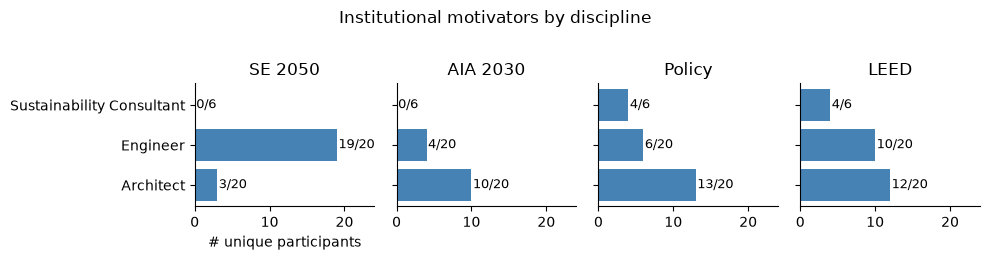

In [44]:
# Institutional motivators by discipline.
#
# Masks are restricted to the MOTIVATION question and exclude negated tags
# (', NO' also catches ', NOT'). Matching on the bare programme name would also
# pick up 'RESULTS: LCA results are reported to (CP - SE 2050)', conflating
# being motivated by a programme with reporting results to it, and would count
# the negated 'CP - SE 2050, NO' tag as a positive.
MOTIV = "MOTIVATION: Our firm's motivation for LCA is"
is_motiv = (df_merged['TAG2'].str.startswith(MOTIV, na=False)
            & ~df_merged['TAG2'].str.contains(', NO', na=False))

institutional_tags = {
    'SE 2050':  is_motiv & df_merged['TAG2'].str.contains('CP - SE 2050', na=False),
    'AIA 2030': is_motiv & df_merged['TAG2'].str.contains('CP - AIA 2030', na=False),
    # Policy rolls up the unqualified tag plus jurisdiction-specific variants
    # (Cal GREEN, MN B3, City Requirement).
    'Policy':   is_motiv & df_merged['TAG2'].str.contains(r'\(Policy', na=False, regex=True),
    'LEED':     is_motiv & df_merged['TAG2'].str.contains('GBC - LEED)', na=False, regex=False),
}

fig, axes = plt.subplots(1, len(institutional_tags), figsize=(10, 2.5), sharey=True)
for ax, (label, mask) in zip(axes, institutional_tags.items()):
    counts = participant_counts(df_merged[mask], 'Arch/Eng')
    ax.barh(counts.index, counts['n'], color='steelblue')
    for i, (idx, row) in enumerate(counts.iterrows()):
        ax.text(row['n'] + 0.2, i, row['label'], va='center', fontsize=9)
    ax.set_xlim(0, 24)
    ax.set_title(label)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_xlabel('# unique participants')
fig.suptitle("Institutional motivators by discipline", y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway1_InstitutionalMotivators.png', bbox_inches='tight', dpi=dpi)

# Participants citing at least one institutional motivator. The four panels above
# are specific programmes; the universality check below rolls up ALL green
# building certifications (WELL, ILFI, Green Globes, ...) and ALL policy variants,
# since the claim is about institutions generally, not LEED specifically.
any_inst = (institutional_tags['SE 2050'] | institutional_tags['AIA 2030']
            | institutional_tags['Policy']
            | (is_motiv & df_merged['TAG2'].str.contains(r'\(GBC', na=False, regex=True)))
n_any = df_merged.loc[any_inst, 'ID'].nunique()
n_gbc = df_merged.loc[is_motiv & df_merged['TAG2'].str.contains(r'\(GBC', na=False, regex=True), 'ID'].nunique()
print(f'at least one institutional motivator: {n_any} of {len(df_demog)}')
print(f'any green building certification:     {n_gbc} of {len(df_demog)}')
for label, mask in institutional_tags.items():
    n = df_merged.loc[mask, 'ID'].nunique()
    print(f'  {label:<9} {n:>2} of {len(df_demog)} ({n / len(df_demog):.0%})')

## Takeaway 2: Material quantity takeoffs are a major point of friction

Quantity takeoffs are near-universal in practice: 41 of 46 participants (89%) described where their material quantities come from, and Revit is by far the dominant source (39 of 46, 85%).

**Friction with that workflow was volunteered by 33 of 46 participants (72%)** — 26 (57%) described difficulty navigating BIM models and 18 (39%) difficulty quantifying materials, with 11 raising both. Difficulty navigating BIM is the third most frequently raised problem in the study, behind only data inaccuracy (43 of 46) and reliability of results (28 of 46). The friction is flat across demographics: 12 of 20 architects, 16 of 20 engineers, and 5 of 6 consultants; 17 of 23 large, 10 of 14 medium, and 6 of 9 small firms; 23 of 31 high- and 10 of 15 low-involvement practitioners.

The one demographic nuance is in the *source* of quantities: architects disproportionately depend on the structural engineer (8 of 20, versus 1 of 20 engineers), adding a cross-disciplinary coordination dependency that engineers do not face.

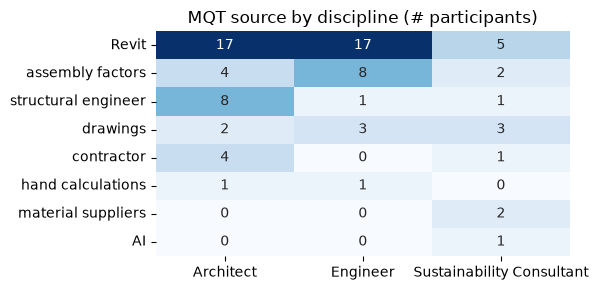

In [45]:
# MQT source by discipline
mqt_cat = 'DATA: Material quantity takeoffs come from'
df_mqt = df_merged[df_merged['TAG2_cat'] == mqt_cat].copy()
df_mqt['source'] = df_mqt['TAG2'].str[len(mqt_cat) + 2:-1]

# pivot: disciplines as columns, sources as rows
pivot = df_mqt.pivot_table(index='source', columns='Arch/Eng', values='ID',
                            aggfunc='nunique', fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pivot.drop(columns='Total').iloc[:8], cmap='Blues', annot=True,
            fmt='d', cbar=False, ax=ax)
ax.set_title('MQT source by discipline (# participants)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway2_MQTSource.png', bbox_inches='tight', dpi=dpi)

## Takeaway 3: Data quality remains a persistent issue

The most demographically uniform finding in the study. **Data inaccuracy was raised by 43 of 46 participants (93%)** — the single most frequently cited problem — and **reliability of results by 28 of 46 (61%)**, with no meaningful differentiation by discipline (inaccuracy: 19 of 20 architects, 18 of 20 engineers, 6 of 6 consultants), role, firm size, or involvement. Lack of standardization follows at 24 of 46 (52%).

One small signal, on a low base: sustainability consultants proportionally flag results as non-comparable more often (3 of 6, versus 2 of 20 architects and 4 of 20 engineers), plausibly reflecting their cross-firm exposure. Only 9 participants raised that code at all, so treat it as suggestive rather than established.

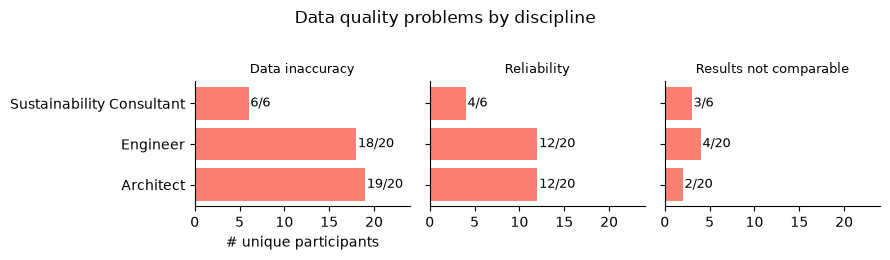

In [46]:
# Data quality problems by discipline
dq_tags = {
    'Data inaccuracy':      df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (data inaccuracy)',
    'Reliability':          df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (reliability of results)',
    'Results not comparable': df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (results are not comparable)',
}

fig, axes = plt.subplots(1, len(dq_tags), figsize=(9, 2.5), sharey=True)
for ax, (label, mask) in zip(axes, dq_tags.items()):
    counts = participant_counts(df_merged[mask], 'Arch/Eng')
    ax.barh(counts.index, counts['n'], color='salmon')
    for i, (idx, row) in enumerate(counts.iterrows()):
        ax.text(row['n'] + 0.2, i, row['label'], va='center', fontsize=9)
    ax.set_xlim(0, 24)
    ax.set_title(label, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_xlabel('# unique participants')
fig.suptitle("Data quality problems by discipline", y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway3_DataQuality.png', bbox_inches='tight')

participants who discussed biogenic carbon: 40 of 46

Exclude biogenic C -- 18 of 46 participants
    by Discipline   Architect 9/20 (45%), Engineer 9/20 (45%), Sustainability Consultant 0/6 (0%)
    by Involvement  High 10/31 (32%), Low 8/15 (53%)
    by Firm size    Large 7/23 (30%), Medium 5/14 (36%), Small 6/9 (67%)

Report separately -- 16 of 46 participants
    by Discipline   Architect 7/20 (35%), Engineer 7/20 (35%), Sustainability Consultant 2/6 (33%)
    by Involvement  High 11/31 (35%), Low 5/15 (33%)
    by Firm size    Large 9/23 (39%), Medium 3/14 (21%), Small 4/9 (44%)

Unclear assumptions -- 14 of 46 participants
    by Discipline   Architect 9/20 (45%), Engineer 4/20 (20%), Sustainability Consultant 1/6 (17%)
    by Involvement  High 9/31 (29%), Low 5/15 (33%)
    by Firm size    Large 7/23 (30%), Medium 3/14 (21%), Small 4/9 (44%)



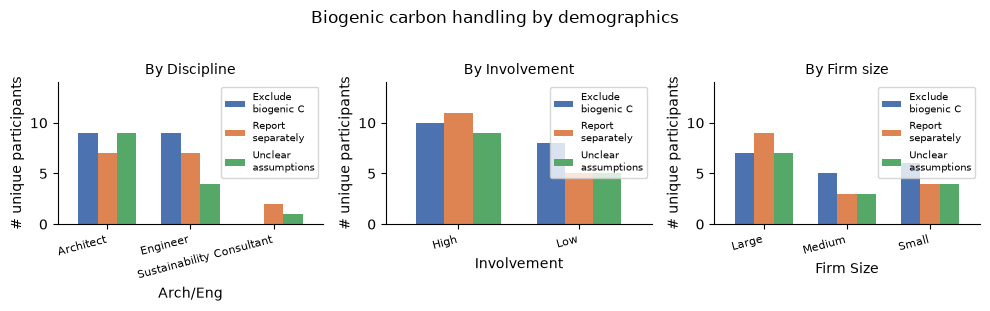

In [47]:
# Biogenic carbon claims by demographics
# 40/46 participants touched on biogenic carbon. Three meaningful demographic
# splits emerge: (1) no sustainability consultant excludes biogenic C;
# (2) architects cite unclear assumptions at twice the rate of engineers;
# (3) low-involvement and small-firm practitioners more often simply exclude it.

bio_claims = {
    'Exclude\nbiogenic C':   df_merged['TAG2'] == 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I (exclude it)',
    'Report\nseparately':    df_merged['TAG2'] == 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I (report it separately)',
    'Unclear\nassumptions':  df_merged['TAG2'] == 'BIOGENIC CARBON: The underlying assumptions are unclear',
}

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
demo_pairs = [
    ('Arch/Eng',    'Discipline'),
    ('Involvement', 'Involvement'),
    ('Firm Size',   'Firm size'),
]

for ax, (demo_col, demo_label) in zip(axes, demo_pairs):
    claim_df = pd.DataFrame({
        label: participant_counts(df_merged[mask], demo_col)['n']
        for label, mask in bio_claims.items()
    })
    claim_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'], width=0.7)
    ax.set_title(f'By {demo_label}', fontsize=10)
    ax.set_ylabel('# unique participants')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, 14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Biogenic carbon handling by demographics', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway3_BiogenicCarbon.png', bbox_inches='tight')

# Key proportions for reference -- computed, not hardcoded, so they stay in sync
n_bio = df_merged.loc[df_merged['CATEGORY'] == 'BIOGENIC CARBON', 'ID'].nunique()
print(f'participants who discussed biogenic carbon: {n_bio} of {len(df_demog)}')
print()
for label, mask in bio_claims.items():
    flat = label.replace('\n', ' ')
    n = df_merged.loc[mask, 'ID'].nunique()
    print(f'{flat} -- {n} of {len(df_demog)} participants')
    for demo_col, demo_label in demo_pairs:
        counts = participant_counts(df_merged[mask], demo_col)
        parts = [f"{idx} {row['n']}/{row['total']} ({row['n'] / row['total']:.0%})"
                 for idx, row in counts.iterrows()]
        print(f'    by {demo_label:<12} ' + ', '.join(parts))
    print()

## Takeaway 4: Advanced LCA methods are compelling but qualified

All 46 participants discussed advanced methods, but that reflects the interview protocol — everyone was asked — rather than universal interest. The substantive measure is **receptiveness**: 23 of 46 (50%) said they could incorporate PLCA and 20 of 46 (43%) DLCA, with 26 of 46 (57%) receptive to at least one and 17 to both. Receptiveness skews strongly toward architects (14 of 20 for each method, versus 5 of 20 and 3 of 20 engineers).

**Prior awareness is very low**: only 2 of 46 (4%) had heard of PLCA — both sustainability consultants — and 8 of 46 (17%) had heard of DLCA (2 of 6 consultants, 3 of 20 architects, 3 of 20 engineers). Sustainability consultants are proportionally more aware of both.

Barriers are consistent across all groups: complexity (17 of 46) and learning curve (16 of 46), with no clear differentiation by role (learning curve: 5 of 12 Project Designers, 5 of 12 Associates, 4 of 16 Project Managers, 2 of 6 Principals/CEOs) or by involvement. The most common qualifier is difficulty of use (13 of 46); only 6 of 46 tied adoption to client demand, too few to support a demographic split.

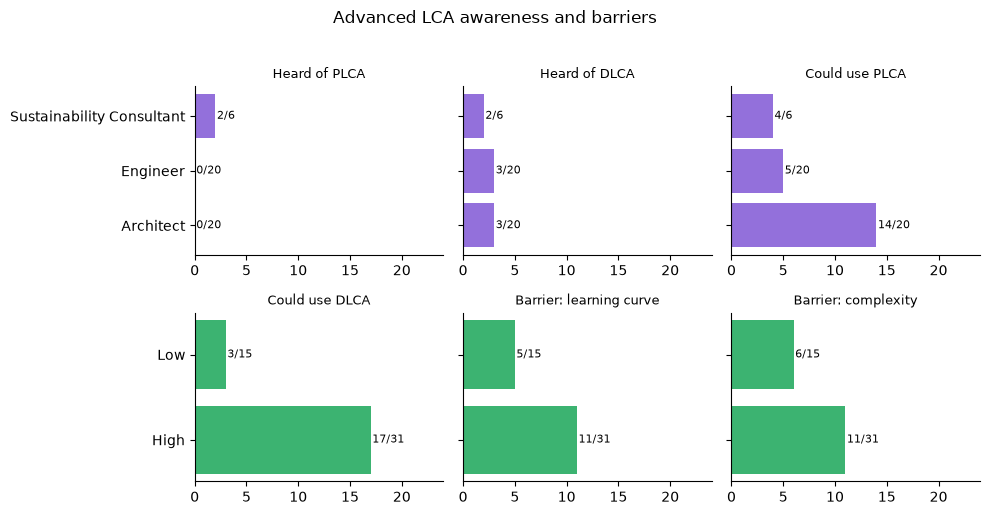

In [48]:
# Advanced LCA awareness and barriers by discipline and involvement
adv_tags = {
    'Heard of PLCA':    df_merged['TAG2'] == 'PLCA: I have heard of PLCA',
    'Heard of DLCA':    df_merged['TAG2'] == 'DLCA: I have heard of DLCA',
    'Could use PLCA':   df_merged['TAG2'] == 'PLCA: I could incorporate PLCA in my practice',
    'Could use DLCA':   df_merged['TAG2'] == 'DLCA: I could incorporate DLCA in my practice',
    'Barrier: learning curve': df_merged['TAG2'].str.contains('barrier.*learning curve', na=False, regex=True),
    'Barrier: complexity':     df_merged['TAG2'].str.contains('barrier.*complexity', na=False, regex=True),
}

fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharey='row')
demo_keys = ['Arch/Eng', 'Involvement']
colors = ['mediumpurple', 'mediumseagreen']

for row_i, demo_col in enumerate(demo_keys):
    for col_i, (label, mask) in enumerate(list(adv_tags.items())[:3] if row_i == 0 else list(adv_tags.items())[3:]):
        ax = axes[row_i, col_i % 3]
        counts = participant_counts(df_merged[mask], demo_col)
        ax.barh(counts.index, counts['n'], color=colors[row_i])
        for i, (idx, row) in enumerate(counts.iterrows()):
            ax.text(row['n'] + 0.15, i, row['label'], va='center', fontsize=8)
        ax.set_xlim(0, 24)
        ax.set_title(label, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("Advanced LCA awareness and barriers", y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway4_AdvancedLCA.png', bbox_inches='tight')

## Additional takeaways

**LCA timing is late, and low involvement makes it later.** Low-involvement practitioners disproportionately start at CD (9 of 15, 60%) versus high-involvement practitioners (11 of 31, 35%), by which point major design decisions are already locked. Starting at SD is common in both groups and does not differentiate them (15 of 31 high versus 8 of 15 low). Counts use the exact phase tag; substring matching would additionally capture aspirational variants such as '(SD, ideally)'.

**LCA scope is discipline-associated.** Half of engineers report A1–A3 scope (10 of 20), versus 5 of 20 architects and 1 of 6 consultants. Full A–C scope is more common among sustainability consultants (5 of 6) and high-involvement practitioners (15 of 31, versus 3 of 15 low-involvement).

**Training burden falls on mid-level practitioners.** Difficulty training others was raised by 14 of 46 participants overall, concentrated in the mid-level roles expected to build organizational capacity: 6 of 12 Project Designers and 5 of 16 Project Managers, versus 2 of 12 Associates/Shareholders and 1 of 6 Principals/CEOs. On-the-job learning remains the dominant pathway (27 of 46), well ahead of university coursework (11 of 46).

**Low-involvement practitioners' barrier is organizational, not technical.** This group disproportionately cites "LCAs are undervalued" (8 of 15, 53%, versus 8 of 31, 26%) and difficulty prioritizing LCA over other work (6 of 15, 40%, versus 5 of 31, 16%), suggesting that for practitioners on the margin the obstacle is cultural rather than methodological.

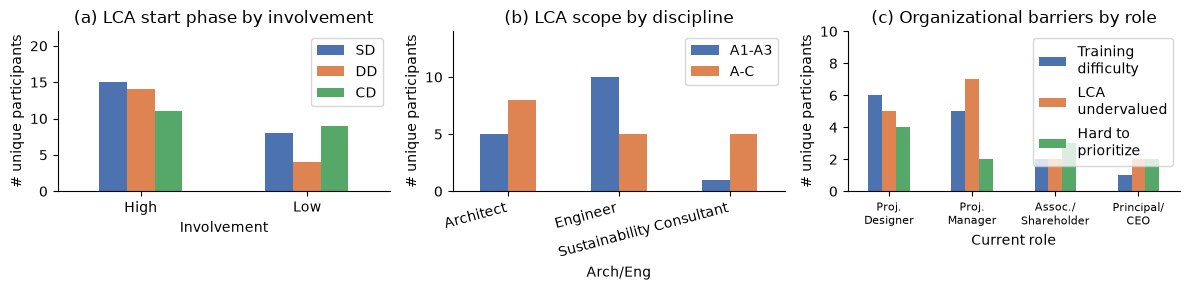

In [49]:
# Additional takeaways: timing, scope, training burden

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# (a) LCA start phase by involvement.
# Match the exact tag rather than a substring: 'during (SD' would also capture
# qualified variants such as '(SD, ideally)' and '(CD, if done once)', which
# state an aspiration rather than current practice. Using exact tags keeps this
# figure consistent with the summary table exported above.
PHASE = 'PHASE: Our firm generally starts LCAs during'
phase_tags = {'SD': f'{PHASE} (SD)', 'DD': f'{PHASE} (DD)', 'CD': f'{PHASE} (CD)'}
phase_counts = {}
for phase, tagname in phase_tags.items():
    mask = df_merged['TAG2'] == tagname
    phase_counts[phase] = participant_counts(df_merged[mask], 'Involvement')['n']
df_phase = pd.DataFrame(phase_counts)
df_phase.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('(a) LCA start phase by involvement')
axes[0].set_ylabel('# unique participants')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylim(0, 22)
axes[0].spines[['top', 'right']].set_visible(False)

# (b) LCA scope (modules) by discipline
scope_tags = {'A1-A3': 'modules (A1-A3)', 'A-C': 'modules (A-C)'}
scope_counts = {}
for scope, substr in scope_tags.items():
    mask = df_merged['TAG2'].str.contains(substr, na=False, regex=False)
    scope_counts[scope] = participant_counts(df_merged[mask], 'Arch/Eng')['n']
df_scope = pd.DataFrame(scope_counts)
df_scope.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('(b) LCA scope by discipline')
axes[1].set_ylabel('# unique participants')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].set_ylim(0, 14)
axes[1].spines[['top', 'right']].set_visible(False)

# (c) Training burden and organizational undervaluation by role
burden_tags = {
    'Training\ndifficulty': df_merged['TAG2'] == 'PROBLEM: It is difficult to (train others to do LCA)',
    'LCA\nundervalued':     df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (LCAs are under valued)',
    'Hard to\nprioritize':  df_merged['TAG2'] == 'PROBLEM: It is difficult to (prioritize LCA over other work)',
}
role_order = ['Project Designer', 'Project Manager', 'Associate/Shareholder', 'Principal/CEO']
burden_df = pd.DataFrame(
    {label: participant_counts(df_merged[mask], 'Current role')['n'].reindex(role_order, fill_value=0)
     for label, mask in burden_tags.items()}
)
burden_df.plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452', '#55A868'])
axes[2].set_title('(c) Organizational barriers by role')
axes[2].set_ylabel('# unique participants')
axes[2].set_xticklabels(['Proj.\nDesigner', 'Proj.\nManager', 'Assoc./\nShareholder', 'Principal/\nCEO'],
                         rotation=0, fontsize=8)
axes[2].set_ylim(0, 10)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_AdditionalTakeaways.png', bbox_inches='tight')

# Manuscript claim verification

Every numeric claim made in the manuscript, recomputed from the data. Each row
prints the manuscript's stated value alongside the value derived here; any row
marked FAIL indicates the manuscript and the data disagree.

Counts are unique participants out of 46 unless stated otherwise. All counts are
of participants who *volunteered* a topic in a semi-structured interview, so each
is a lower bound on prevalence rather than a response rate.

In [50]:
# Recompute every numeric claim in the manuscript.
N = len(df_demog)
S = df_merged['TAG2']
DEMOG = df_demog.set_index('ID')

def ids_where(mask):
    return set(df_merged.loc[mask, 'ID'])

def tag(t):
    return ids_where(S == t)

def n_in(ids, col=None, value=None, disc=None):
    """Count ids within a demographic cell, and that cell's size."""
    grp = [i for i in DEMOG.index
           if (col is None or DEMOG.loc[i, col] == value)
           and (disc is None or DEMOG.loc[i, 'Arch/Eng'] == disc)]
    return len([i for i in grp if i in ids]), len(grp)

checks = []
def check(section, claim, stated, actual):
    ok = (stated == actual)
    checks.append((section, claim, stated, actual, ok))

MOTIV = "MOTIVATION: Our firm's motivation for LCA is"
LEARN = 'LEARNING: A resource I use for learning LCA is'
MQT   = 'DATA: Material quantity takeoffs come from'
PROB  = 'PROBLEM: A problem with LCAs is'
DIFF  = 'PROBLEM: It is difficult to'
BIO   = 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I'

inacc   = tag(f'{PROB} (data inaccuracy)')
relia   = tag(f'{PROB} (reliability of results)')
navbim  = tag(f'{DIFF} (navigate BIM)')
qtymat  = tag(f'{DIFF} (quantify materials)')
bench   = tag(f'{DIFF} (define an EC benchmark)')
stdz    = tag(f'{PROB} (lack of standardization)')
revit   = tag(f'{MQT} (Revit)')
assembly= tag(f'{MQT} (assembly factors)')
struct  = tag(f'{MQT} (structural engineer)')
leed    = tag(f'{MOTIV} (GBC - LEED)')
clf     = tag(f'{LEARN} (CLF)')
se2050L = tag(f'{LEARN} (SE 2050)')
onjob   = tag(f'{LEARN} (on the job)')
univ    = tag(f'{LEARN} (university)')
ease    = tag('PRIORITY: In LCA tools, I prioritize (ease-of-use)')
exclude = tag(f'{BIO} (exclude it)')
report  = tag(f'{BIO} (report it separately)')
unclear = tag('BIOGENIC CARBON: The underlying assumptions are unclear')
anybio  = ids_where(S.str.startswith('BIOGENIC CARBON'))
notP    = tag('PLCA: I have heard of PLCA, NOT')
notD    = tag('DLCA: I have heard of DLCA, NOT')
heardP  = tag('PLCA: I have heard of PLCA')
heardD  = tag('DLCA: I have heard of DLCA')
goodP   = tag('PLCA: PLCA seems like a good idea')
canP    = tag('PLCA: I could incorporate PLCA in my practice')
canD    = tag('DLCA: I could incorporate DLCA in my practice')
interest= tag('ADVANCED LCA: I am interested to learn more about advanced LCA methods')
clientd = tag('ADVANCED LCA: Whether I use advanced LCA methods depends on (client demand)')
anybar  = ids_where(S.str.contains('barrier to adopting', na=False))
acscope = ids_where(S.str.contains('modules (A-C)', regex=False))
a13     = ids_where(S.str.contains('modules (A1-A3)', regex=False))

# --- Abstract / 3.3 ---
check('Abstract/3.3', 'data inaccuracy 43 (93%)', 43, len(inacc))
check('3.3', 'reliability of results 28 (61%)', 28, len(relia))
# --- 3.1 ---
check('3.1', 'LEED cited by 26 (57%)', 26, len(leed))
check('3.1', 'CLF 2nd-most-cited learning resource, 17 (37%)', 17, len(clf))
check('3.1', 'SE 2050 4th-most-cited learning resource, 13 (28%)', 13, len(se2050L))
check('3.1', 'on-the-job most common pathway, 27 (59%)', 27, len(onjob))
check('3.1', 'EC benchmark difficulty 19 (41%)', 19, len(bench))
check('3.1', 'lack of standardization 24 (52%)', 24, len(stdz))
# --- 3.2 ---
check('3.2', 'Revit as MQT source 39 (85%)', 39, len(revit))
check('3.2', 'difficulty navigating BIM 26 (57%)', 26, len(navbim))
check('3.2', 'difficulty quantifying materials 18 (39%)', 18, len(qtymat))
check('3.2', 'either friction code 33 (72%)', 33, len(navbim | qtymat))
check('3.2', 'both friction codes 11', 11, len(navbim & qtymat))
check('3.2', 'assembly factors 14 (30%)', 14, len(assembly))
check('3.2', 'assembly-factor users who do NOT also use Revit: 0', 0, len(assembly - revit))
check('3.2', 'ease-of-use top priority 32 (70%)', 32, len(ease))
check('3.2', 'architects sourcing from structural engineer 8/20', 8, n_in(struct, disc='Architect')[0])
check('3.2', 'engineers sourcing from structural engineer 1/20', 1, n_in(struct, disc='Engineer')[0])
# --- 3.3 biogenic ---
check('3.3', 'biogenic carbon raised by 40 (87%)', 40, len(anybio))
check('3.3', 'unclear assumptions 14 (30%)', 14, len(unclear))
check('3.3', 'exclude biogenic 18 (39%)', 18, len(exclude))
check('3.3', 'report separately 16 (35%)', 16, len(report))
check('3.3', 'consultants excluding biogenic 0/6', 0, n_in(exclude, disc='Sustainability Consultant')[0])
check('3.3', 'architects excluding biogenic 9/20', 9, n_in(exclude, disc='Architect')[0])
check('3.3', 'engineers excluding biogenic 9/20', 9, n_in(exclude, disc='Engineer')[0])
check('3.3', 'consultants who raised biogenic carbon 5', 5, n_in(anybio, disc='Sustainability Consultant')[0])
check('3.3', 'architects flagging unclear assumptions 9/20', 9, n_in(unclear, disc='Architect')[0])
check('3.3', 'engineers flagging unclear assumptions 4/20', 4, n_in(unclear, disc='Engineer')[0])
check('3.3', 'architects full A-C scope 8/20', 8, n_in(acscope, disc='Architect')[0])
check('3.3', 'engineers full A-C scope 5/20', 5, n_in(acscope, disc='Engineer')[0])
check('3.3', 'engineers A1-A3 scope 10/20', 10, n_in(a13, disc='Engineer')[0])
check('3.3', 'architects A1-A3 scope 5/20', 5, n_in(a13, disc='Architect')[0])
check('3.3', 'architects discussing biogenic 17/20', 17, n_in(anybio, disc='Architect')[0])
check('3.3', 'engineers discussing biogenic 18/20', 18, n_in(anybio, disc='Engineer')[0])
check('3.3', 'small firms excluding biogenic 6/9', 6, n_in(exclude, 'Firm Size', 'Small')[0])
check('3.3', 'medium firms excluding biogenic 5/14', 5, n_in(exclude, 'Firm Size', 'Medium')[0])
check('3.3', 'large firms excluding biogenic 7/23', 7, n_in(exclude, 'Firm Size', 'Large')[0])
check('3.3', 'small-firm architects excluding 3/4', 3, n_in(exclude, 'Firm Size', 'Small', 'Architect')[0])
check('3.3', 'large-firm architects excluding 4/11', 4, n_in(exclude, 'Firm Size', 'Large', 'Architect')[0])
check('3.3', 'small-firm engineers excluding 3/4', 3, n_in(exclude, 'Firm Size', 'Small', 'Engineer')[0])
check('3.3', 'large-firm engineers excluding 3/8', 3, n_in(exclude, 'Firm Size', 'Large', 'Engineer')[0])
check('3.3', 'low-involvement excluding biogenic 8/15', 8, n_in(exclude, 'Involvement', 'Low')[0])
check('3.3', 'high-involvement excluding biogenic 10/31', 10, n_in(exclude, 'Involvement', 'High')[0])
check('3.3', 'low-involvement participants who are engineers 11/15', 11,
      len([i for i in DEMOG.index if DEMOG.loc[i, 'Involvement'] == 'Low'
           and DEMOG.loc[i, 'Arch/Eng'] == 'Engineer']))
check('3.3', 'low-involvement engineers excluding 5/11', 5, n_in(exclude, 'Involvement', 'Low', 'Engineer')[0])
check('3.3', 'high-involvement engineers excluding 4/9', 4, n_in(exclude, 'Involvement', 'High', 'Engineer')[0])
check('3.3', 'report separately, architects 7/20', 7, n_in(report, disc='Architect')[0])
check('3.3', 'report separately, engineers 7/20', 7, n_in(report, disc='Engineer')[0])
check('3.3', 'report separately, consultants 2/6', 2, n_in(report, disc='Sustainability Consultant')[0])
check('3.3', 'unclear assumptions, high-involvement 9/31', 9, n_in(unclear, 'Involvement', 'High')[0])
check('3.3', 'unclear assumptions, low-involvement 5/15', 5, n_in(unclear, 'Involvement', 'Low')[0])
# --- 3.3 reliability by capacity ---
check('3.3', 'reliability, small firms 7/9', 7, n_in(relia, 'Firm Size', 'Small')[0])
check('3.3', 'reliability, large firms 11/23', 11, n_in(relia, 'Firm Size', 'Large')[0])
check('3.3', 'reliability, low-involvement 12/15', 12, n_in(relia, 'Involvement', 'Low')[0])
check('3.3', 'reliability, high-involvement 16/31', 16, n_in(relia, 'Involvement', 'High')[0])
# --- 3.4 ---
check('3.4', 'had NOT heard of pLCA 31 (67%)', 31, len(notP))
check('3.4', 'had NOT heard of dLCA 23 (50%)', 23, len(notD))
check('3.4', 'pLCA seems like a good idea 30 (65%)', 30, len(goodP))
check('3.4', 'could incorporate pLCA 23 (50%)', 23, len(canP))
check('3.4', 'could incorporate dLCA 20 (43%)', 20, len(canD))
check('3.4', 'interested to learn more 44 (96%)', 44, len(interest))
check('3.4', 'consultants who had heard of pLCA 2/6', 2, n_in(heardP, disc='Sustainability Consultant')[0])
check('3.4', 'consultants who had heard of dLCA 2/6', 2, n_in(heardD, disc='Sustainability Consultant')[0])

results = pd.DataFrame(checks, columns=['Section', 'Claim', 'Manuscript', 'Data', 'OK'])
results['Result'] = results['OK'].map({True: 'pass', False: 'FAIL'})
n_fail = (~results['OK']).sum()
print(f'{len(results)} claims checked, {n_fail} FAIL')
print()
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 60, 'display.width', 200):
    print(results[['Section', 'Claim', 'Manuscript', 'Data', 'Result']].to_string(index=False))
results.to_excel('outputs/tables/manuscript_claim_checks.xlsx', index=False)

63 claims checked, 0 FAIL

     Section                                                Claim  Manuscript  Data Result
Abstract/3.3                             data inaccuracy 43 (93%)          43    43   pass
         3.3                      reliability of results 28 (61%)          28    28   pass
         3.1                               LEED cited by 26 (57%)          26    26   pass
         3.1       CLF 2nd-most-cited learning resource, 17 (37%)          17    17   pass
         3.1   SE 2050 4th-most-cited learning resource, 13 (28%)          13    13   pass
         3.1             on-the-job most common pathway, 27 (59%)          27    27   pass
         3.1                     EC benchmark difficulty 19 (41%)          19    19   pass
         3.1                     lack of standardization 24 (52%)          24    24   pass
         3.2                         Revit as MQT source 39 (85%)          39    39   pass
         3.2                   difficulty navigating BIM 26 (57

In [51]:
# Claims that are demographic ranges or comparisons rather than single values.
print('data inaccuracy, by subgroup (manuscript states a range):')
worst = 1.0
for col in ['Arch/Eng', 'Firm Size', 'Involvement', 'Current role']:
    counts = participant_counts(df_merged[df_merged['TAG2'] == f'{PROB} (data inaccuracy)'], col)
    parts = []
    for idx, row in counts.iterrows():
        frac = row['n'] / row['total']
        worst = min(worst, frac)
        parts.append(f"{idx} {row['n']}/{row['total']} ({frac:.0%})")
    print(f'   {col:14}', ', '.join(parts))
print(f'   >>> minimum across ALL subgroups: {worst:.0%}')
print()

print('LEED motivation by discipline (manuscript: "more pronounced among architects')
print('and sustainability consultants than structural engineers"):')
print('   ', end='')
counts = participant_counts(df_merged[df_merged['TAG2'] == f'{MOTIV} (GBC - LEED)'], 'Arch/Eng')
print(', '.join(f"{i} {r['n']}/{r['total']} ({r['n']/r['total']:.0%})" for i, r in counts.iterrows()))
print()

print('Barriers to adopting advanced methods, by role (manuscript: principals/CEOs')
print('cite them less often than project-level practitioners):')
for label, mask in [('any "barrier to adopting" tag', S.str.contains('barrier to adopting', na=False)),
                    ('ADVANCED LCA barrier (learning curve)',
                     S == 'ADVANCED LCA: A barrier to adopting advanced LCA methods may be (learning curve)')]:
    counts = participant_counts(df_merged[mask], 'Current role')
    print(f'   {label}:')
    print('      ', ', '.join(f"{i} {r['n']}/{r['total']} ({r['n']/r['total']:.0%})" for i, r in counts.iterrows()))
print()

print('Advanced-LCA adoption contingent on client demand, by involvement:')
counts = participant_counts(
    df_merged[df_merged['TAG2'] == 'ADVANCED LCA: Whether I use advanced LCA methods depends on (client demand)'],
    'Involvement')
print('   ', ', '.join(f"{i} {r['n']}/{r['total']} ({r['n']/r['total']:.0%})" for i, r in counts.iterrows()))
print('   >>> n is small; treat as suggestive only')
print()

print('Program-affiliated vs university learning resources (Conclusion claim):')
prog_tags = [f'{LEARN} ({x})' for x in ['CLF', 'SE 2050', 'SE 2050 ECAPs', 'LEED', 'AIA',
                                        'SEI Prestandard', 'USGBC', 'IStructE']]
prog = ids_where(S.isin(prog_tags))
print(f'   any program-affiliated resource: {len(prog)} of {N} ({len(prog)/N:.0%})')
print(f'   university coursework:           {len(univ)} of {N} ({len(univ)/N:.0%})')
print(f'   program resource but not university: {len(prog - univ)} of {N}')
print()

print('EC benchmark difficulty by involvement and firm size (Conclusion claim that the')
print('need "binds hardest on their most engaged participants"):')
for col in ['Involvement', 'Firm Size']:
    counts = participant_counts(df_merged[df_merged['TAG2'] == f'{DIFF} (define an EC benchmark)'], col)
    print(f'   {col:12}', ', '.join(f"{i} {r['n']}/{r['total']} ({r['n']/r['total']:.0%})" for i, r in counts.iterrows()))

data inaccuracy, by subgroup (manuscript states a range):
   Arch/Eng       Architect 19/20 (95%), Engineer 18/20 (90%), Sustainability Consultant 6/6 (100%)
   Firm Size      Large 21/23 (91%), Medium 13/14 (93%), Small 9/9 (100%)
   Involvement    High 29/31 (94%), Low 14/15 (93%)
   Current role   Associate/Shareholder 10/12 (83%), Principal/CEO 5/6 (83%), Project Designer 12/12 (100%), Project Manager 16/16 (100%)
   >>> minimum across ALL subgroups: 83%

LEED motivation by discipline (manuscript: "more pronounced among architects
and sustainability consultants than structural engineers"):
   Architect 12/20 (60%), Engineer 10/20 (50%), Sustainability Consultant 4/6 (67%)

Barriers to adopting advanced methods, by role (manuscript: principals/CEOs
cite them less often than project-level practitioners):
   any "barrier to adopting" tag:
       Associate/Shareholder 10/12 (83%), Principal/CEO 3/6 (50%), Project Designer 10/12 (83%), Project Manager 11/16 (69%)
   ADVANCED LCA barrier

# Graphical abstract

A single wide figure summarising the study for the journal's graphical abstract
slot. The four numbered panels correspond one-to-one with the four key takeaways
in the Results and Conclusion, so a reader who has just seen "four key takeaways
emerged" finds four panels here. Every value is computed from the data rather
than typed in, so the figure cannot drift from the analysis.

Sized for Elsevier's specification: minimum 1328 x 531 px and legible at
13 x 5 cm. The figure is 5.12 x 2.05 in at 600 dpi, giving 3072 x 1230 px at a
2.5:1 aspect ratio, so nominal point sizes render at their true size when the
figure is placed at 13 cm wide.

The four hues were checked with a colour-vision-deficiency validator across all
pairs, not just adjacent ones, since all four panels are visible at once: worst
CVD dE 9.2, worst normal-vision dE 16.3, both clear of their floors. Two slots
fall below 3:1 contrast against the surface, so every bar carries a direct value
label rather than relying on colour alone. Within each panel the three codes are
disjoint -- no bar is a subset of another -- so the panel never shows a figure
and its own superset side by side.

GraphicalAbstract.png: 3072 x 1230 px (ratio 2.50:1)
Elsevier minimum 1328 x 531 px: OK
  Institutions drive adoption: Any institution 100%, Green building cert. 70%, Commitment program 67%
  BIM is the bottleneck: Revit for quantities 85%, Navigating BIM 57%, Quantifying materials 39%
  Data quality falls short: Inaccurate carbon data 93%, Unreliable results 61%, Biogenic unclear 30%
  Open to advanced LCA: Want to learn more 96%, pLCA appealing 65%, Could adopt pLCA 50%


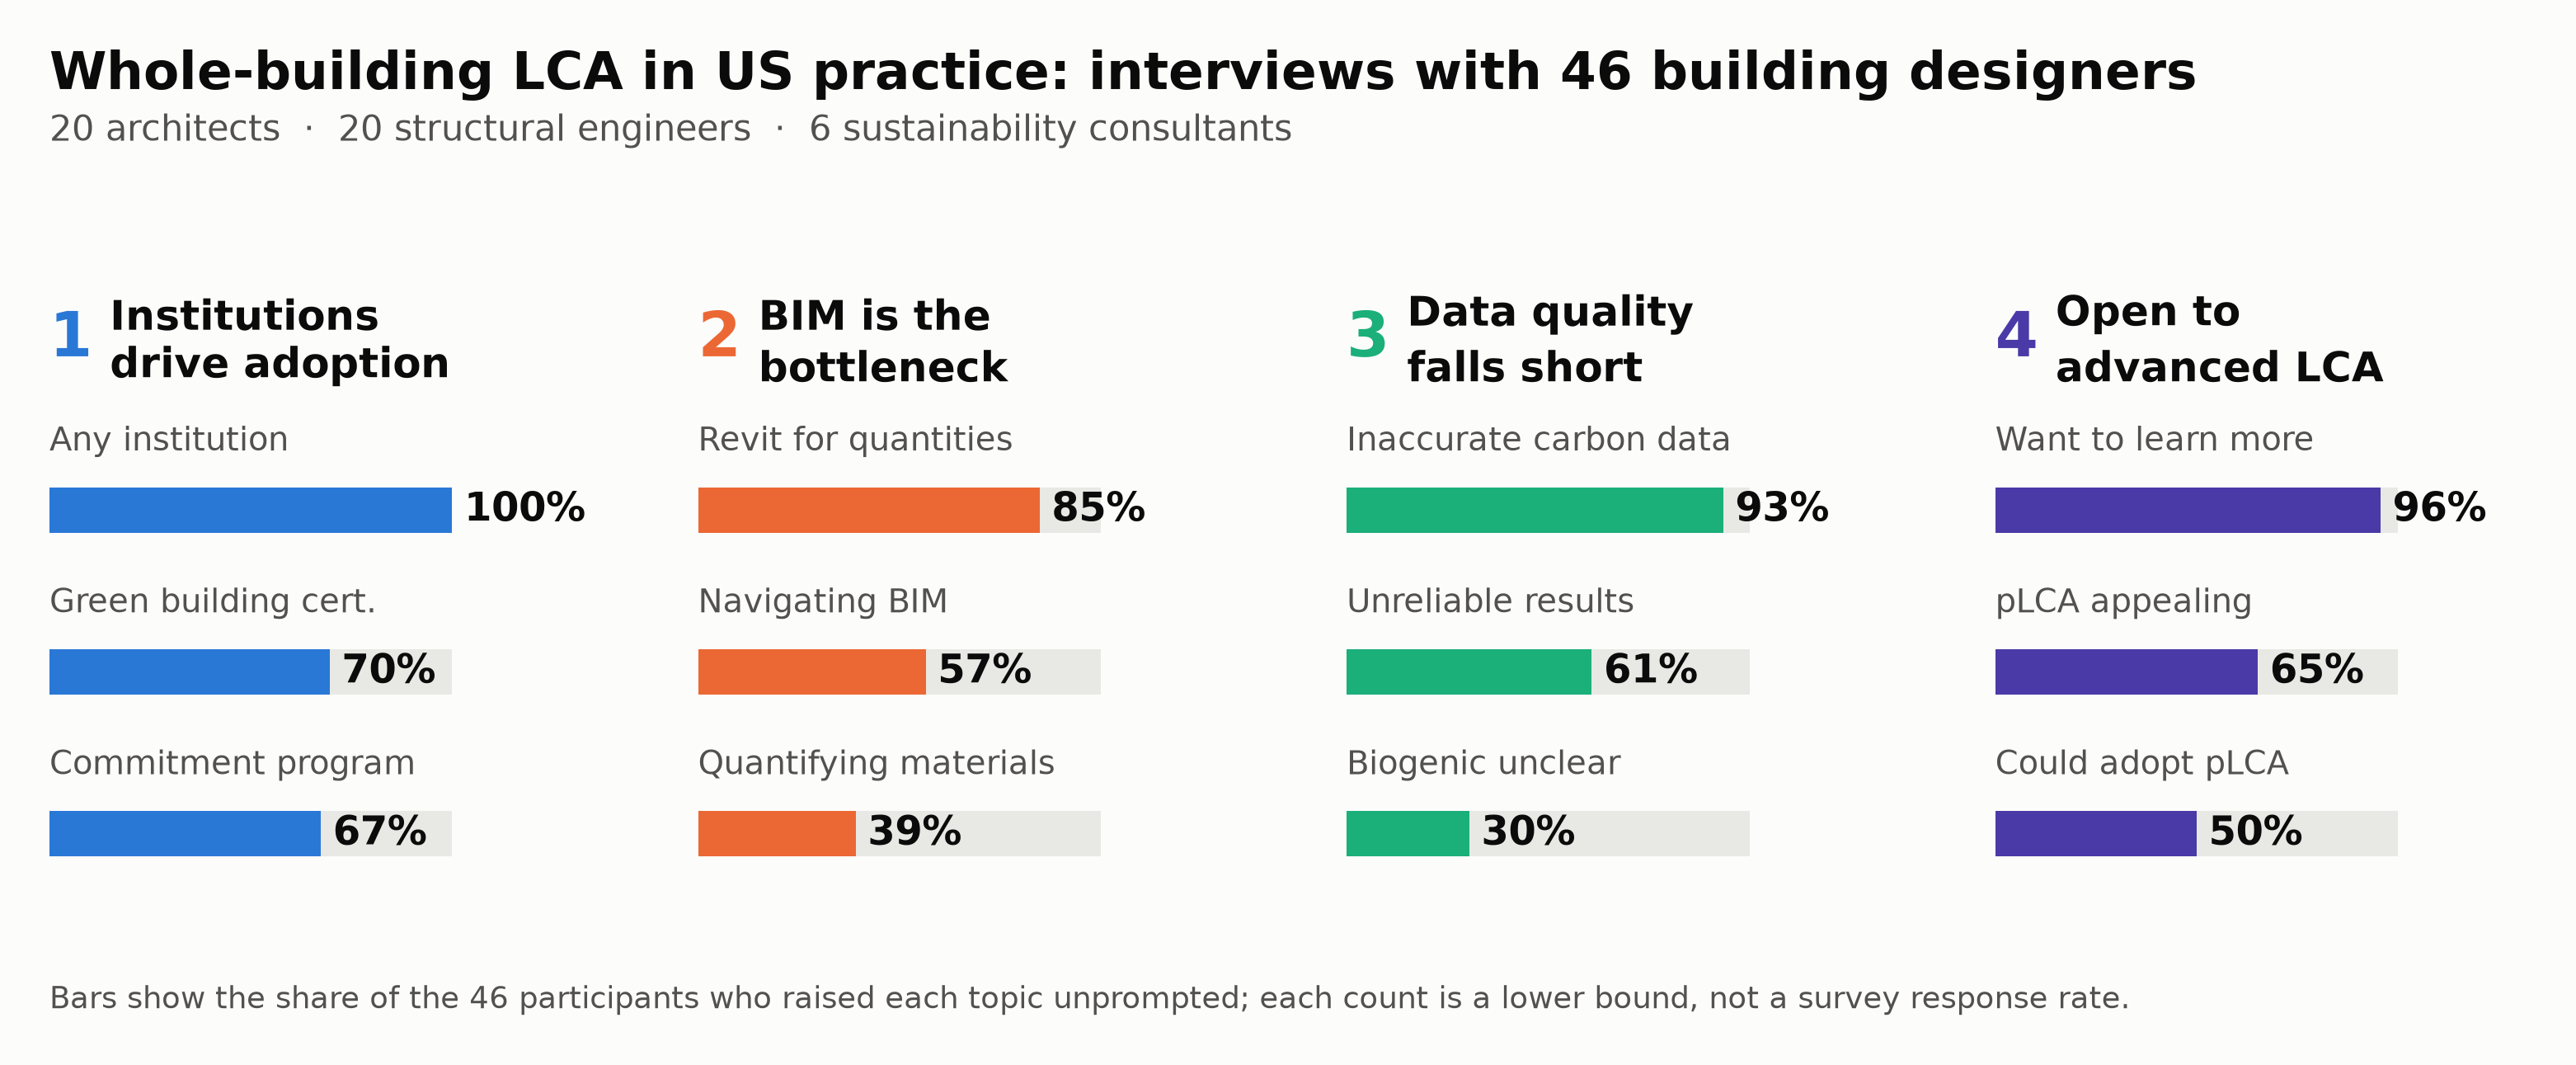

In [52]:
# Graphical abstract -- four panels, one per key takeaway. All values computed.
S = df_tags['TAG2']
N_GA = len(df_demog)

MOTIV_GA = "MOTIVATION: Our firm's motivation for LCA is"
PROB_GA = 'PROBLEM: A problem with LCAs is'
DIFF_GA = 'PROBLEM: It is difficult to'
MQT_GA = 'DATA: Material quantity takeoffs come from'
pos_ga = S.str.startswith(MOTIV_GA) & ~S.str.contains(', NO', na=False)

def ga_ids(mask):
    return set(df_tags.loc[mask, 'ID'])

def ga_pct(s):
    return 100 * len(s) / N_GA

gbc_ga = ga_ids(pos_ga & S.str.contains(r'\(GBC', regex=True))
cp_ga = ga_ids(pos_ga & S.str.startswith(MOTIV_GA + ' (CP'))
policy_ga = ga_ids(pos_ga & S.str.contains(r'\(Policy', regex=True))

ga_panels = [
    ('Institutions\ndrive adoption', '#2a78d6', [
        ('Any institution', ga_pct(gbc_ga | cp_ga | policy_ga)),
        ('Green building cert.', ga_pct(gbc_ga)),
        ('Commitment program', ga_pct(cp_ga)),
    ]),
    ('BIM is the\nbottleneck', '#eb6834', [
        ('Revit for quantities', ga_pct(ga_ids(S == f'{MQT_GA} (Revit)'))),
        ('Navigating BIM', ga_pct(ga_ids(S == f'{DIFF_GA} (navigate BIM)'))),
        ('Quantifying materials', ga_pct(ga_ids(S == f'{DIFF_GA} (quantify materials)'))),
    ]),
    ('Data quality\nfalls short', '#1baf7a', [
        ('Inaccurate carbon data', ga_pct(ga_ids(S == f'{PROB_GA} (data inaccuracy)'))),
        ('Unreliable results', ga_pct(ga_ids(S == f'{PROB_GA} (reliability of results)'))),
        ('Biogenic unclear',
         ga_pct(ga_ids(S == 'BIOGENIC CARBON: The underlying assumptions are unclear'))),
    ]),
    ('Open to\nadvanced LCA', '#4a3aa7', [
        ('Want to learn more',
         ga_pct(ga_ids(S == 'ADVANCED LCA: I am interested to learn more about advanced LCA methods'))),
        ('pLCA appealing', ga_pct(ga_ids(S == 'PLCA: PLCA seems like a good idea'))),
        ('Could adopt pLCA', ga_pct(ga_ids(S == 'PLCA: I could incorporate PLCA in my practice'))),
    ]),
]

SURFACE, TEXT_PRI, TEXT_SEC, TRACK = '#fcfcfb', '#0b0b0b', '#52514e', '#e8e8e4'

fig, axes = plt.subplots(1, 4, figsize=(5.12, 2.05), dpi=600)
fig.patch.set_facecolor(SURFACE)

for n, (ax, (title, hue, items)) in enumerate(zip(axes, ga_panels), start=1):
    ax.set_facecolor(SURFACE)
    for i, (label, value) in enumerate(items):
        ax.barh(i, 100, height=0.28, color=TRACK, zorder=1)   # track shows the denominator
        ax.barh(i, value, height=0.28, color=hue, zorder=3)
        ax.text(0, i - 0.32, label, ha='left', va='bottom', fontsize=4.8, color=TEXT_SEC)
        ax.text(value + 3, i, f'{value:.0f}%', ha='left', va='center',
                fontsize=5.8, color=TEXT_PRI, fontweight='bold')
    ax.text(0, -1.05, str(n), ha='left', va='center', fontsize=9.0,
            color=hue, fontweight='bold')
    ax.text(15, -1.05, title, ha='left', va='center', fontsize=6.0,
            color=TEXT_PRI, fontweight='bold', linespacing=1.25)
    ax.set_xlim(0, 132)
    ax.set_ylim(len(items) - 0.55, -1.75)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.suptitle(f'Whole-building LCA in US practice: interviews with {N_GA} building designers',
             fontsize=7.6, color=TEXT_PRI, fontweight='bold', x=0.012, ha='left', y=0.975)
disc = df_demog['Arch/Eng'].value_counts()
fig.text(0.012, 0.885,
         f"{disc['Architect']} architects  ·  {disc['Engineer']} structural engineers  "
         f"·  {disc['Sustainability Consultant']} sustainability consultants",
         fontsize=5.2, color=TEXT_SEC, ha='left')
fig.text(0.012, 0.030,
         f'Bars show the share of the {N_GA} participants who raised each topic unprompted; '
         'each count is a lower bound, not a survey response rate.',
         fontsize=4.4, color=TEXT_SEC, ha='left')

fig.subplots_adjust(left=0.012, right=0.99, top=0.80, bottom=0.13, wspace=0.22)
fig.savefig('outputs/figures/GraphicalAbstract.png', facecolor=SURFACE, dpi=600)
fig.savefig('outputs/figures/GraphicalAbstract.pdf', facecolor=SURFACE)   # vector, for submission

import matplotlib.image as mpimg
_ga = mpimg.imread('outputs/figures/GraphicalAbstract.png')
print(f'GraphicalAbstract.png: {_ga.shape[1]} x {_ga.shape[0]} px '
      f'(ratio {_ga.shape[1] / _ga.shape[0]:.2f}:1)')
print('Elsevier minimum 1328 x 531 px:',
      'OK' if _ga.shape[1] >= 1328 and _ga.shape[0] >= 531 else 'TOO SMALL')
for title, _, items in ga_panels:
    print(f'  {title.replace(chr(10), " ")}: '
          + ', '.join(f'{l} {v:.0f}%' for l, v in items))